# Photovoltaic Module Temperature Forecasting

## 02 - Exploratory Data Analysis

This notebook explores the processed dataset to understand the distribution, variability and relationships between the variables used for photovoltaic module temperature forecasting.

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.diagnostic import lilliefors

## 2. Data Loading

In [2]:
df = pd.read_csv(
    "../data/processed/pv_module_temperature_clean.csv"
)

df.shape

(42532, 4)

In [3]:
df["UpdatedTime"] = pd.to_datetime(df["UpdatedTime"])

In [4]:
df.dtypes

UpdatedTime           datetime64[us]
IrradianceGlobal             float64
TemperatureAmbient           float64
TemperatureModules           float64
dtype: object

## 3. Descriptive Statistics

In [5]:
df[
    [
        "IrradianceGlobal",
        "TemperatureAmbient",
        "TemperatureModules"
    ]
].describe().round(2)

,IrradianceGlobal,TemperatureAmbient,TemperatureModules
count,42532.00,42532.00,42532.00
mean,560.51,29.06,39.05
std,361.46,4.13,8.85
min,0.10,18.50,17.90
25%,233.90,25.70,31.80
50%,542.60,29.90,39.90
75%,915.90,32.50,46.60
max,1422.90,37.60,62.50


The final dataset contains 42,532 valid observations. Module temperature shows a higher mean and greater variability than ambient temperature, which is expected due to solar heating. Global irradiance spans a wide range of values, from 0.10 to 1422.90 W/m².

The descriptive statistics provide an overview of the central tendency, variability and range of the variables used in the forecasting models.

## 4. Distribution Analysis

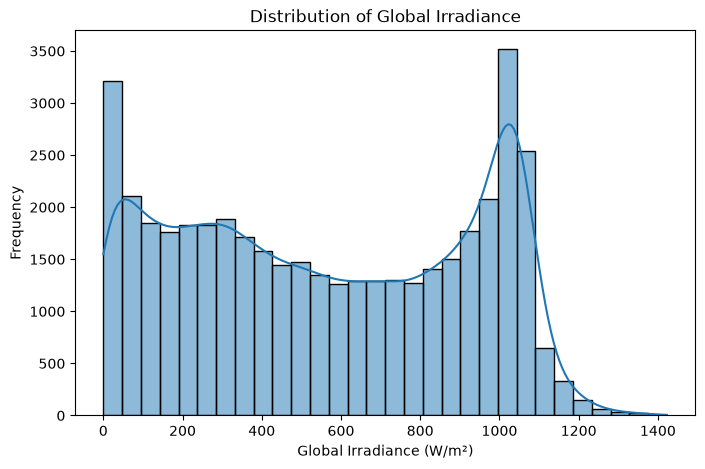

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="IrradianceGlobal",
    bins=30,
    kde=True
)

plt.title("Distribution of Global Irradiance")
plt.xlabel("Global Irradiance (W/m²)")
plt.ylabel("Frequency")
plt.show()

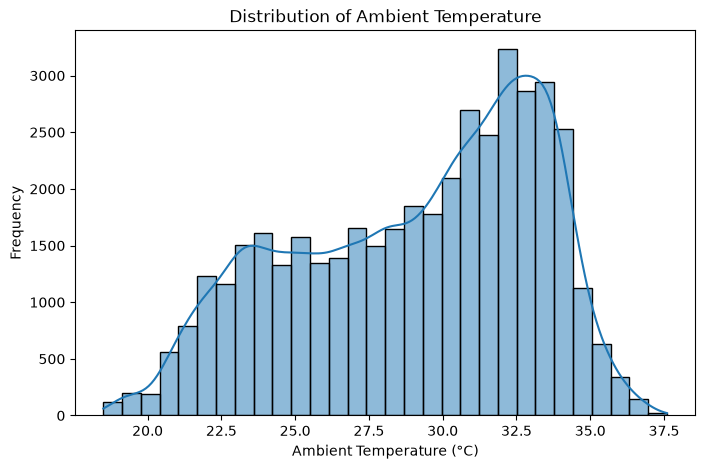

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="TemperatureAmbient",
    bins=30,
    kde=True
)

plt.title("Distribution of Ambient Temperature")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

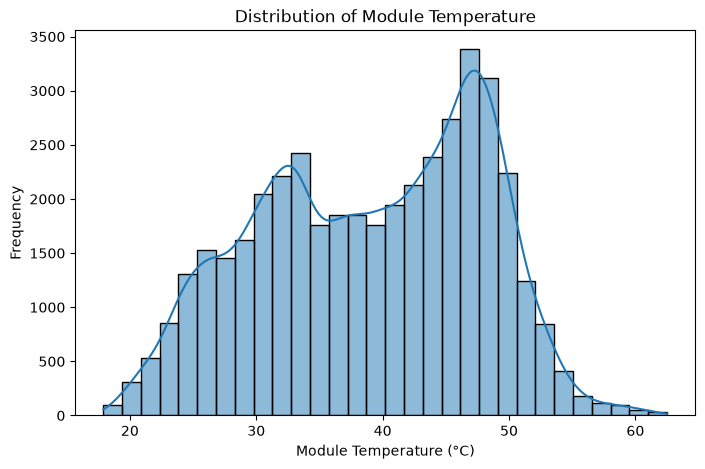

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="TemperatureModules",
    bins=30,
    kde=True
)

plt.title("Distribution of Module Temperature")
plt.xlabel("Module Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

The distributions show different patterns across the analyzed variables. Global irradiance presents high variability, while ambient and module temperatures show concentrations in different ranges. Module temperature presents greater variability than ambient temperature, reflecting the effect of solar irradiance on photovoltaic modules.

## 5. Outlier Analysis

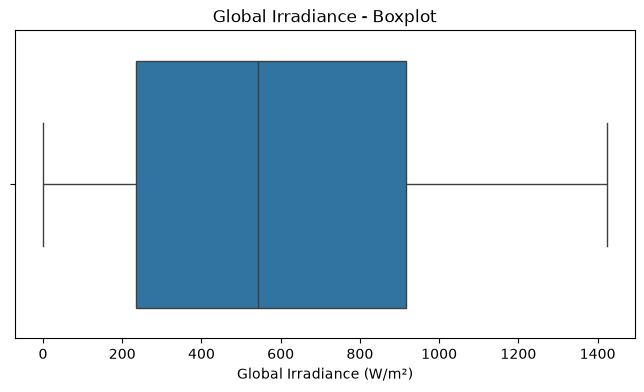

In [10]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="IrradianceGlobal"
)

plt.title("Global Irradiance - Boxplot")
plt.xlabel("Global Irradiance (W/m²)")
plt.show()

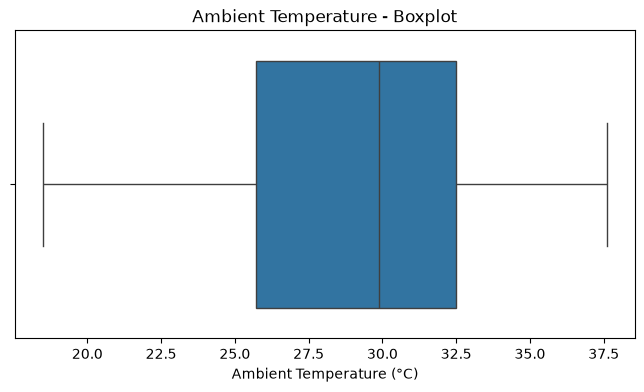

In [11]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="TemperatureAmbient"
)

plt.title("Ambient Temperature - Boxplot")
plt.xlabel("Ambient Temperature (°C)")
plt.show()

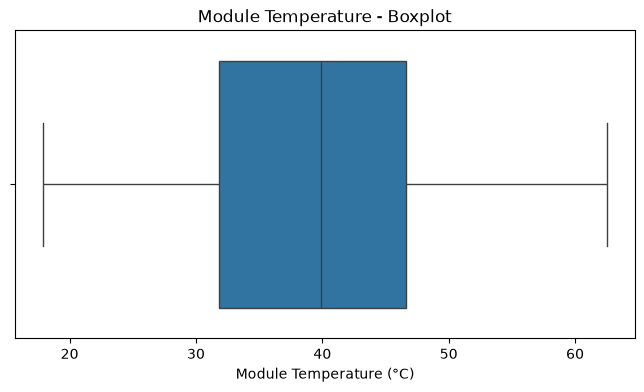

In [12]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="TemperatureModules"
)

plt.title("Module Temperature - Boxplot")
plt.xlabel("Module Temperature (°C)")
plt.show()

After removing invalid zero measurements during data preparation, the boxplots do not indicate relevant outliers in the final dataset. No additional observations were removed at this stage.

## 6. Normality Analysis

In [13]:
statistic, p_value = lilliefors(df["IrradianceGlobal"])

print("Global Irradiance")
print("Statistic:", round(statistic, 4))
print("P-value:", round(p_value, 4))

Global Irradiance
Statistic: 0.0908
P-value: 0.001


In [14]:
statistic, p_value = lilliefors(df["TemperatureAmbient"])

print("Ambient Temperature")
print("Statistic:", round(statistic, 4))
print("P-value:", round(p_value, 4))

Ambient Temperature
Statistic: 0.0922
P-value: 0.001


In [15]:
statistic, p_value = lilliefors(df["TemperatureModules"])

print("Module Temperature")
print("Statistic:", round(statistic, 4))
print("P-value:", round(p_value, 4))

Module Temperature
Statistic: 0.0798
P-value: 0.001


Normality test interpretation: The Lilliefors test returned p-values below 0.05 for Global Irradiance, Ambient Temperature, and Module Temperature. Therefore, the null hypothesis of normality is rejected for all variables, indicating that their distributions significantly deviate from a normal distribution. Considering this result, Spearman's rank correlation is also evaluated in the correlation analysis.

## 7. Correlation Analysis

In [21]:
features = [
    "IrradianceGlobal",
    "TemperatureAmbient",
    "TemperatureModules"
]

pearson_corr = df[features].corr(method="pearson")
spearman_corr = df[features].corr(method="spearman")

print("Pearson Correlation:")
display(pearson_corr.round(3))

print("\nSpearman Correlation:")
display(spearman_corr.round(3))

Pearson Correlation:


,IrradianceGlobal,TemperatureAmbient,TemperatureModules
IrradianceGlobal,1.000,0.187,0.717
TemperatureAmbient,0.187,1.000,0.729
TemperatureModules,0.717,0.729,1.000



Spearman Correlation:


,IrradianceGlobal,TemperatureAmbient,TemperatureModules
IrradianceGlobal,1.000,0.113,0.713
TemperatureAmbient,0.113,1.000,0.675
TemperatureModules,0.713,0.675,1.000


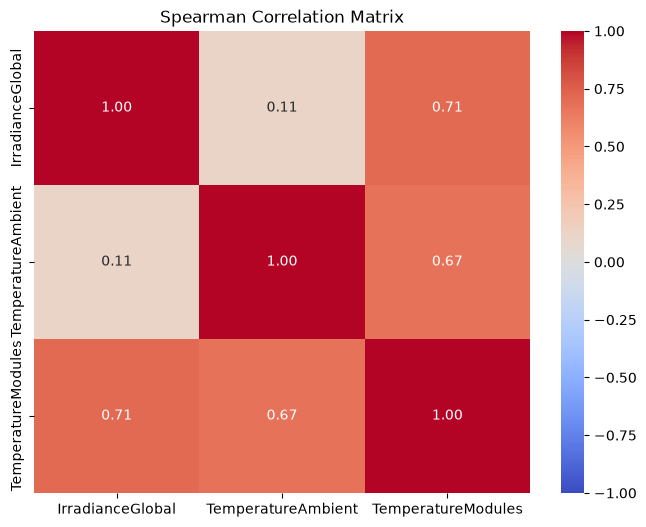

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Spearman Correlation Matrix")
plt.show()

Correlation analysis: Both Pearson and Spearman coefficients indicate consistent positive relationships between the predictor variables and module temperature. Global Irradiance shows a strong association with Module Temperature (Spearman ρ = 0.713), while Ambient Temperature also presents a moderate-to-strong positive association (ρ = 0.675). In contrast, Global Irradiance and Ambient Temperature are weakly correlated (ρ = 0.113), suggesting that they provide complementary information for predicting photovoltaic module temperature.

## 8. Key Findings

- The final processed dataset contains 42,532 valid observations of Global Irradiance, Ambient Temperature, and Module Temperature
- Photovoltaic modules operate at temperatures noticeably above ambient conditions. The average Module Temperature is 39.05 °C, compared with 29.06 °C for Ambient Temperature, reflecting the heating effect associated with solar radiation.
- Global Irradiance spans a wide range, from 0.10 to 1422.90 W/m², while Module Temperature ranges from 17.90 to 62.50 °C, showing the considerable thermal variation experienced by the photovoltaic modules.
- The distribution plots reveal non-normal patterns for the analyzed variables. This observation is confirmed by the Lilliefors normality test, which returned p-values below 0.05 for all three variables.
- After the removal of invalid zero measurements during data preparation, the boxplots do not indicate relevant outliers requiring additional removal.
- Global Irradiance and Ambient Temperature both show relevant positive associations with Module Temperature. Spearman's correlation coefficients are approximately 0.713 and 0.675, respectively.
- Pearson correlation provides similar results, with coefficients of 0.717 for Global Irradiance and 0.729 for Ambient Temperature in relation to Module Temperature, reinforcing the consistency of these relationships.
- Global Irradiance and Ambient Temperature are only weakly correlated with each other (Spearman ρ = 0.113), suggesting that they provide largely complementary information for predicting photovoltaic module temperature.
- Overall, the exploratory analysis supports the use of Global Irradiance and Ambient Temperature as predictor variables in the subsequent machine-learning modeling stage.